# ID dual innervating neurons

In [1]:
import os
from pathlib import Path
import scanpy as sc
from scipy.sparse import issparse
import pandas as pd
import numpy as np
import anndata as ad
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.mixture import GaussianMixture
import session_info
import sys

In [2]:
plt.rcParams['figure.figsize'] = (3, 3)
#plt.rcParams['figure.dpi'] = 300

In [3]:
base_dir = Path('/home/workspace/projects/20251125_drg-backup-slides1-2_gpu')

input_dir = base_dir / "data/h5ad/export_03/03_neuron-scanvi"
#output_dir = base_dir / "data/h5ad/export_03/02_neuron-labels"

#output_dir.mkdir(parents=True, exist_ok=True)

## Read data

In [4]:
adata = sc.read_h5ad(os.path.join(input_dir, 'neuron-scanvi-labels.h5ad'))
adata

AnnData object with n_obs × n_vars = 37176 × 212
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'output_id', 'xenium_run_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'nuclear_fraction', 'doublet_scores', 'predicted_doublets', 'batch', 'slide', '_scvi_batch', '_scvi_labels', 'scvi_model', 'leiden_scVI_1', 'cell_class', 'neuron_recluster', 'scanvi_labels'
    var: 'Ensembl ID', 'Probesets', 'zhen_list', 'spectral_panel', 'neurons_supervised', 'neurons_unsupervised', 'glia_supervised', 'glia_unsupervised', 'other', 'neuron_DEGs', 'neuron_detection_rate', 'glia_detection_rate', 'combined_detection_rate

In [5]:
genes = {
    "Pan-neuronal": ["Nefl", "Nefm", ],
    "Ab Field-LTMR": ["Ntrk3", "Hapln1", "F2r", "Ntng1", "Slc17a7", "Piezo2"],
    "Ab RA-LTMR": ["Htr7", "Hapln1", "Htr3b", "F2r", "Ntng1", "Ndst4", "Piezo2"],
    "Ad-LTMR": ["Aldh1l1", "Cox6a2", "Htr7", "Htr3b", "F2r"],
    "C-LTMR": ["Lyve1", "Htr1d", ],  
    "CGRP-a": ["Calca", "Calcb", 'Tac1', "Sstr2", "Chrnb3", "Bcl6", "Bcl11a", "Trpv1"],
    "CGRP-e": ["Oprk1", "Tlr4", "Asic3", "Asic3", "Htr1a"],
    "CGRP-h": ["Bmpr1b", "Prokr2", "Chrna3", "Chrnb4", "Chrna3"],
    "CGRP-g": ["Adra2a", "Ctcflos", "Chrnb4", "Mrap2", "Col25a1"],
    "CGRP-q1": ["Mrgpra3", "Hrh1", "Kcnq3", "Gda"],
    "CGRP-q2": ["Mrgprb4", "Kcnq3"],
    "CGRP-z": ["Smr2", "Chrna3", "Asic3", "Gm765"],
    "CGRP-l": ["Calca", "Ntrk2", "Htr4", "Il31ra"],
    "Nonpeptidergic nociceptors (Mrgprd+)": ["Mrgprd", "Mlip", "Nppb"],
    "Proprioceptors": ["Spp1", "Gabra3", "Il1r1"],
    "Sst": ["Sst", "F2rl1", "Cysltr2"],
    "Trpm8": ["Trpm8", "Tox", "Htr1f"],
}

In [6]:
plt.rcParams.update({"font.size": 16})

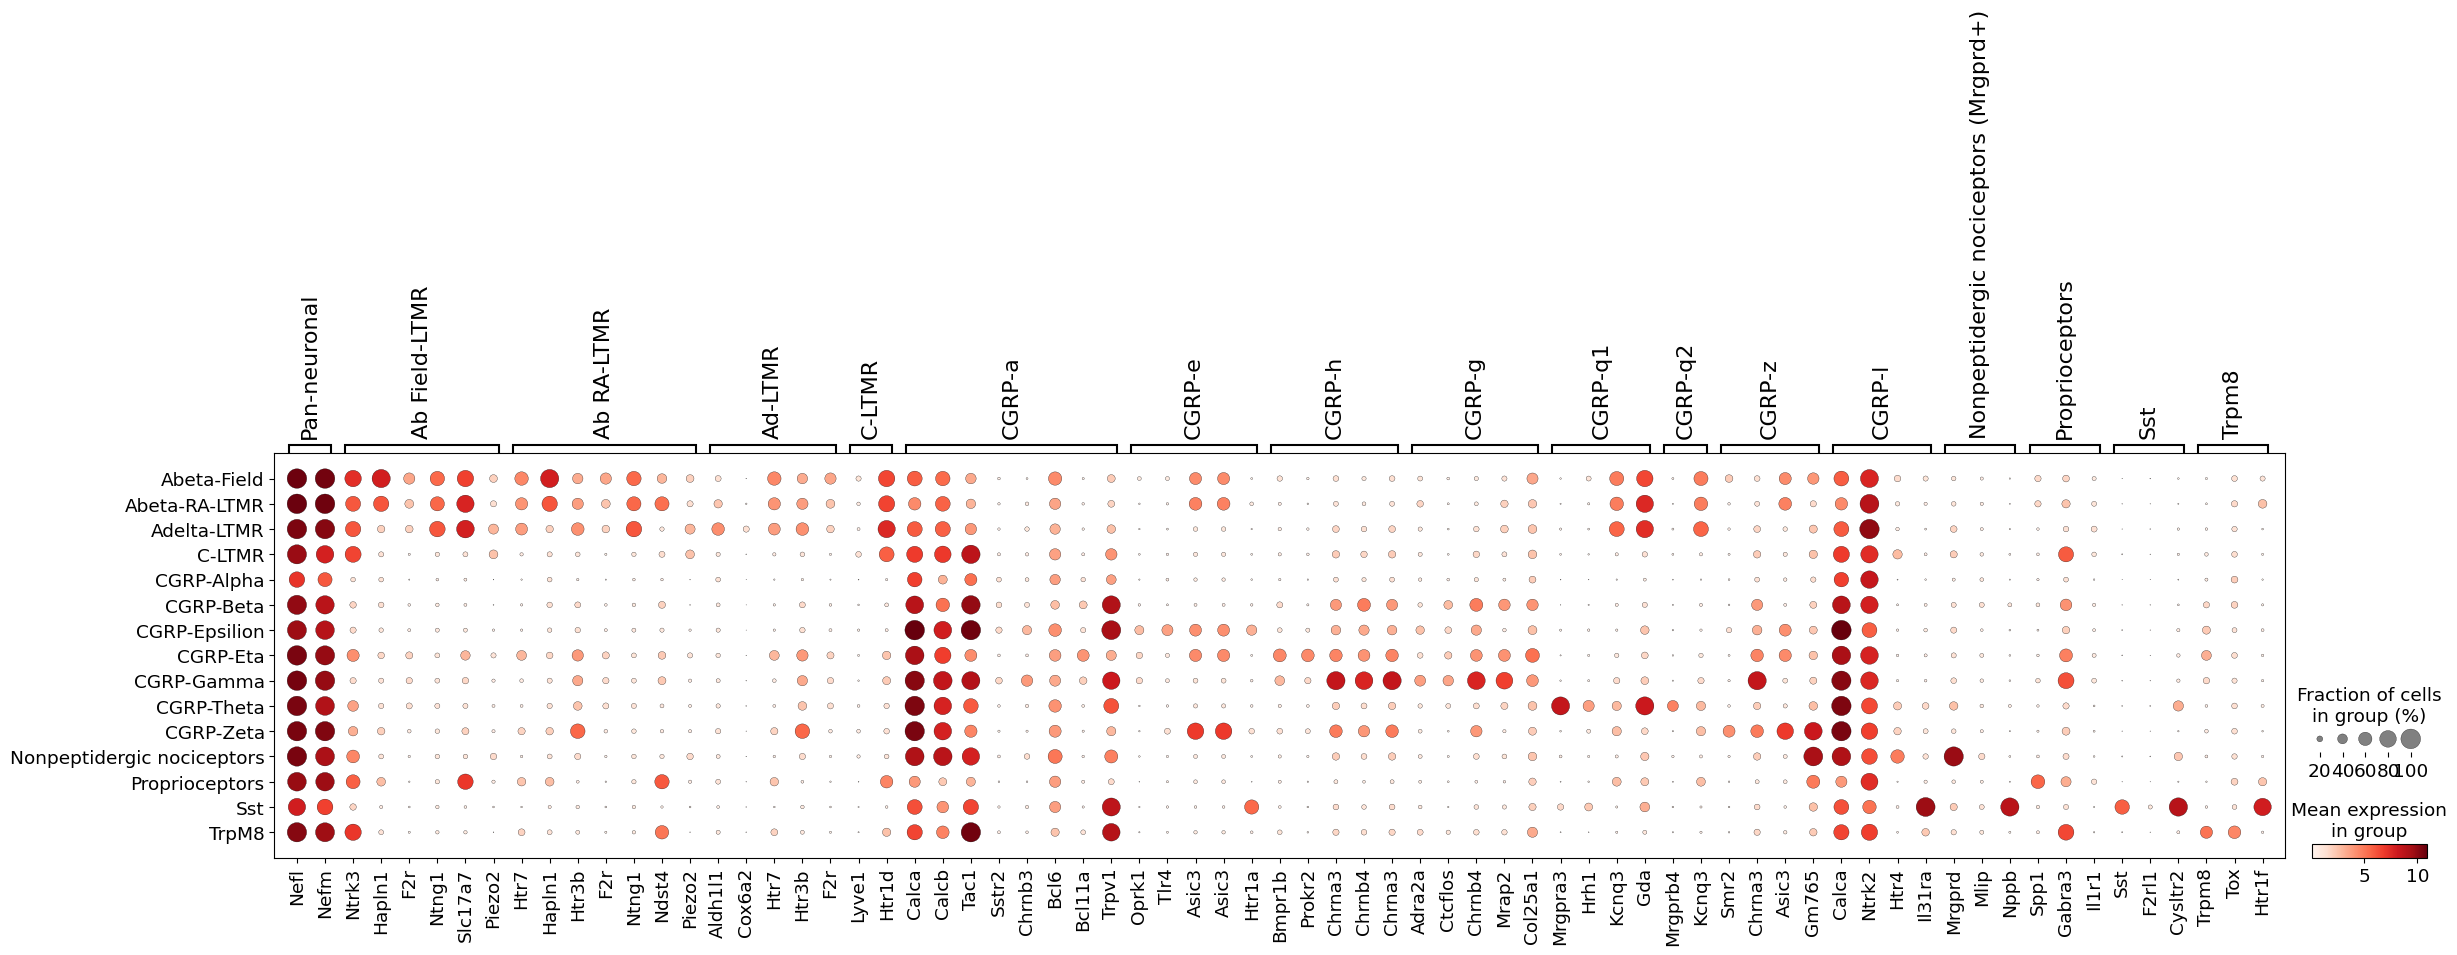

In [7]:
sc.pl.dotplot(adata, var_names = genes, groupby = 'scanvi_labels')#, standard_scale = 'var')

categories: 0, 1, 2, etc.
var_group_labels: Pan-neuronal, Ab Field-LTMR, Ab RA-LTMR, etc.


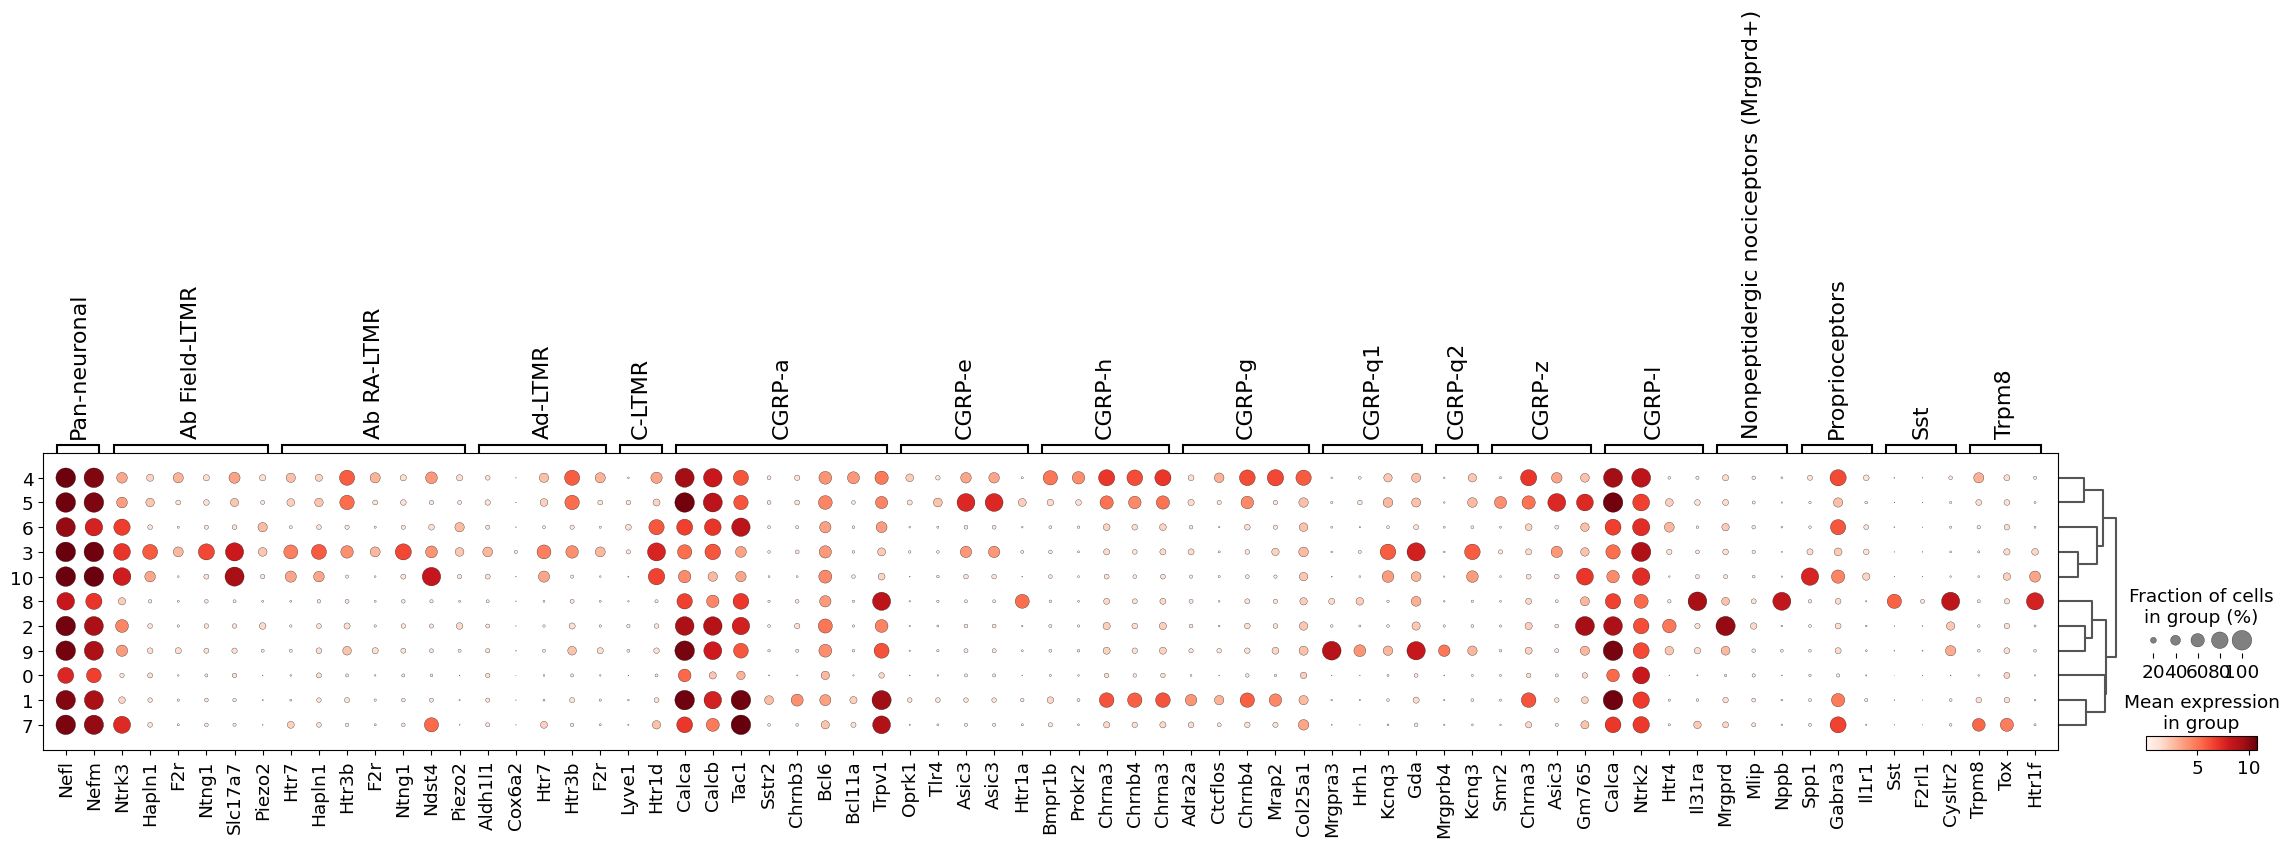

In [8]:
sc.pl.dotplot(adata, var_names = genes, groupby = 'neuron_recluster', dendrogram = True)

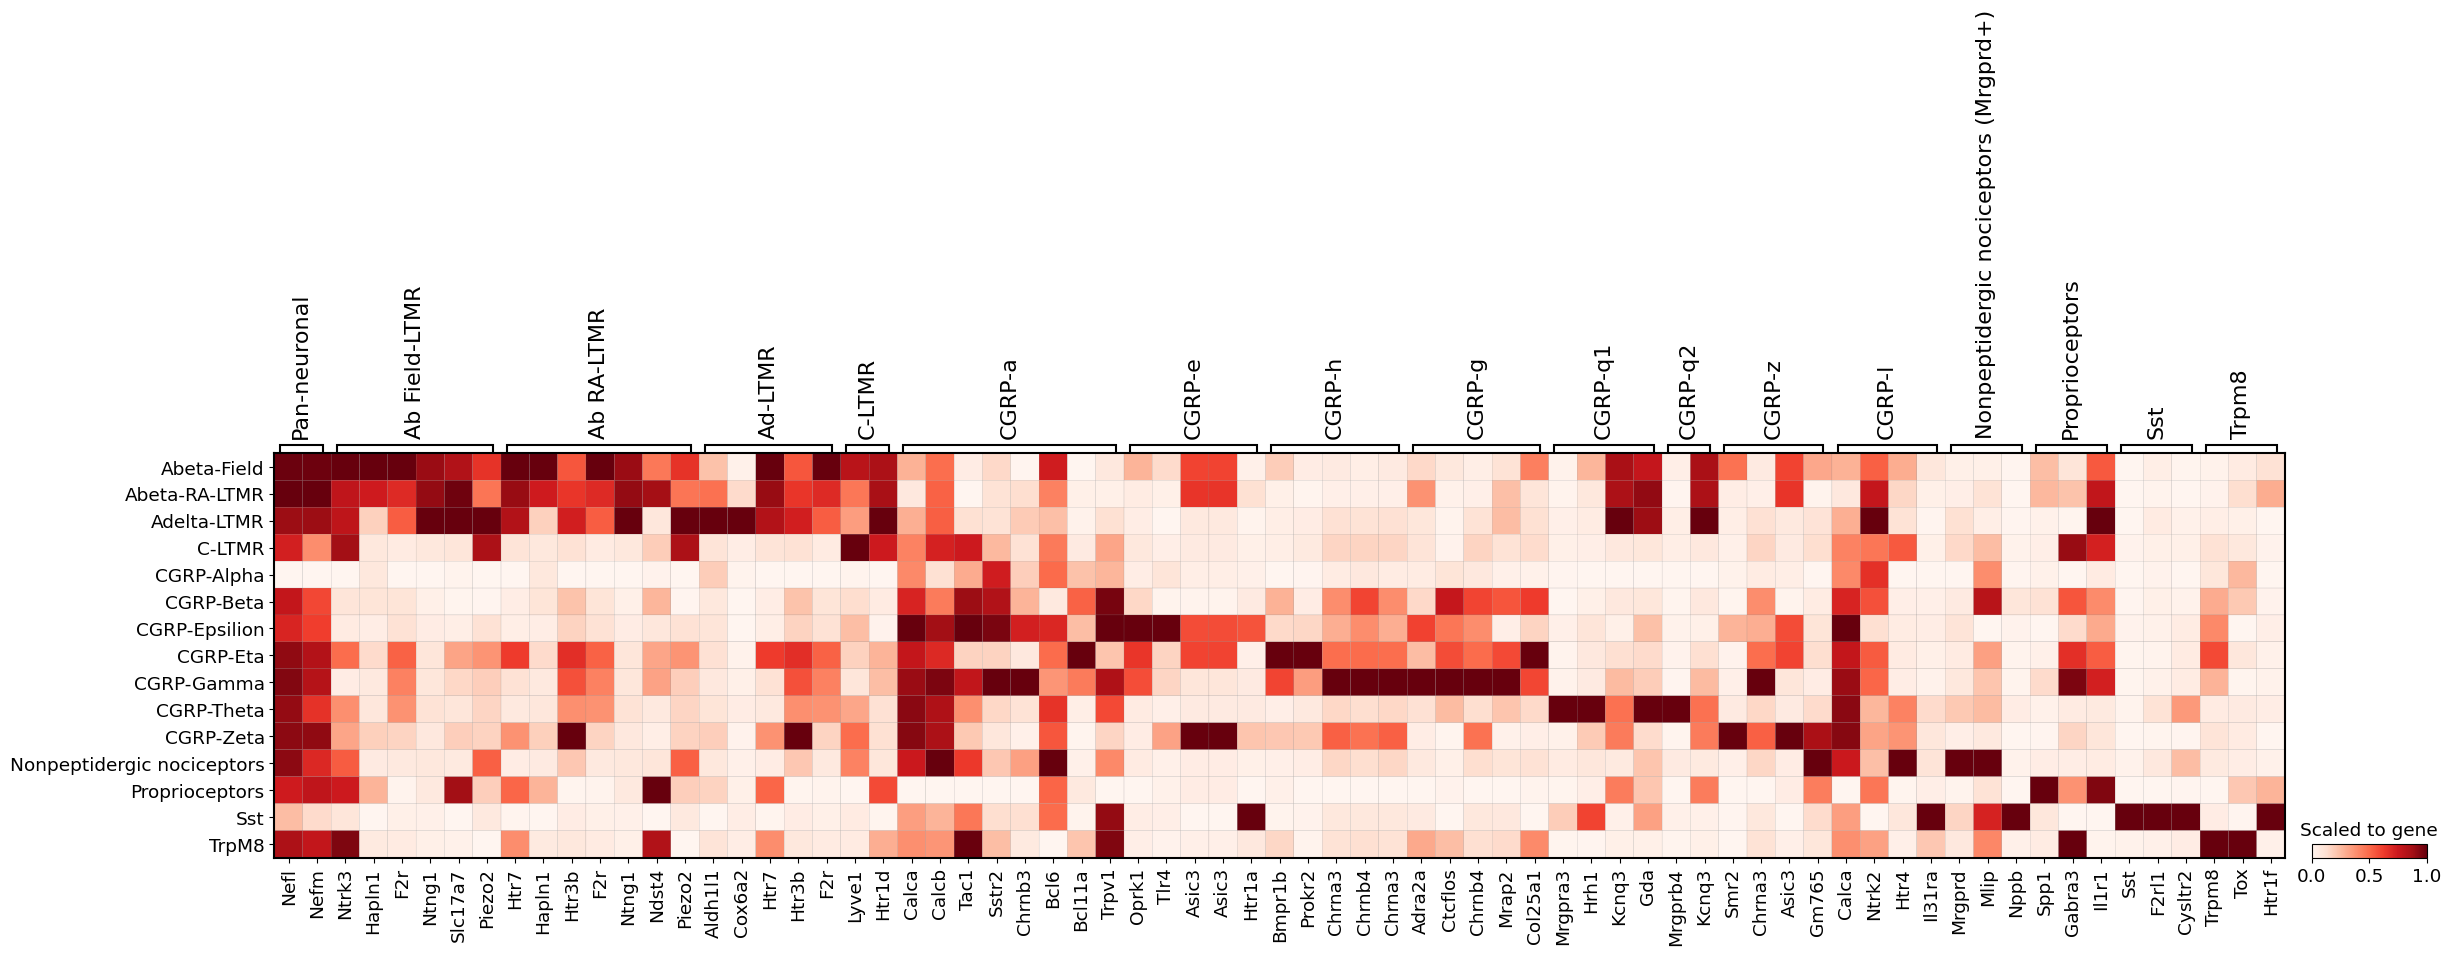

In [9]:
sc.pl.matrixplot(adata, var_names = genes, groupby = 'scanvi_labels', standard_scale = 'var', cmap = 'Reds', colorbar_title = 'Scaled to gene')

categories: 0, 1, 2, etc.
var_group_labels: Pan-neuronal, Ab Field-LTMR, Ab RA-LTMR, etc.


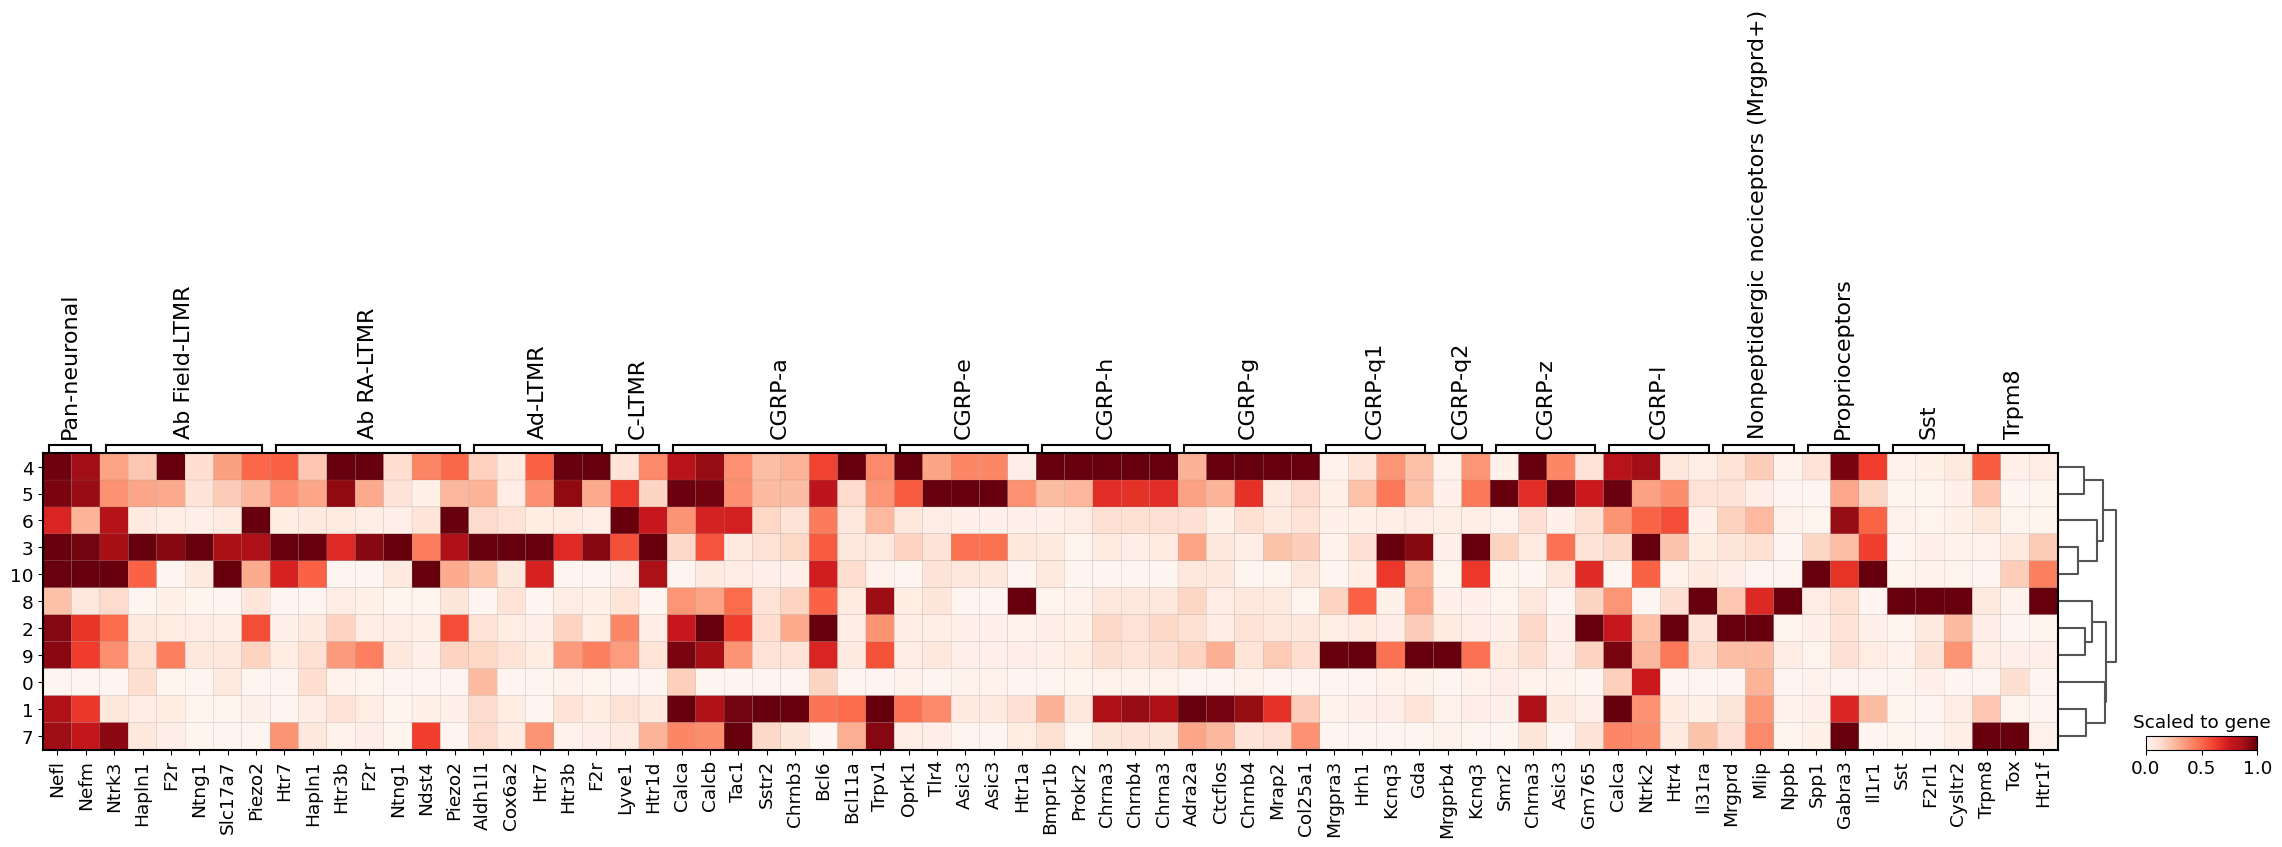

In [10]:
sc.pl.matrixplot(adata, var_names = genes, groupby = 'neuron_recluster', standard_scale = 'var', cmap = 'Reds', colorbar_title = 'Scaled to gene', dendrogram = True)

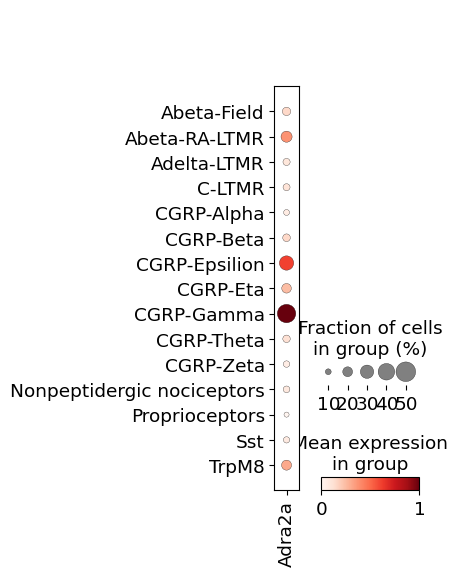

In [11]:
genes = ['Adra2a']
sc.pl.dotplot(adata, var_names = genes, groupby = 'scanvi_labels', standard_scale = 'var', cmap = 'Reds')

In [36]:
sc.pl.dotplot(adata, var_names = 'Adra2a', groupby = 'neuron_recluster',  cmap = 'Reds')

ValueError: groupby has to be a valid observation. Given neuron_recluster, is not in observations: ['cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'output_id', 'xenium_run_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'nuclear_fraction', 'doublet_scores', 'predicted_doublets', 'batch', 'slide', '_scvi_batch', '_scvi_labels', 'scvi_model', 'leiden_scVI_1', 'EGFP_Seq1_hi', 'tdTomato_Seq2_hi', 'EGFP_tdTomato_dual_hi']

In [13]:
adata

AnnData object with n_obs × n_vars = 37176 × 212
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'output_id', 'xenium_run_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'nuclear_fraction', 'doublet_scores', 'predicted_doublets', 'batch', 'slide', '_scvi_batch', '_scvi_labels', 'scvi_model', 'leiden_scVI_1', 'cell_class', 'neuron_recluster', 'scanvi_labels'
    var: 'Ensembl ID', 'Probesets', 'zhen_list', 'spectral_panel', 'neurons_supervised', 'neurons_unsupervised', 'glia_supervised', 'glia_unsupervised', 'other', 'neuron_DEGs', 'neuron_detection_rate', 'glia_detection_rate', 'combined_detection_rate

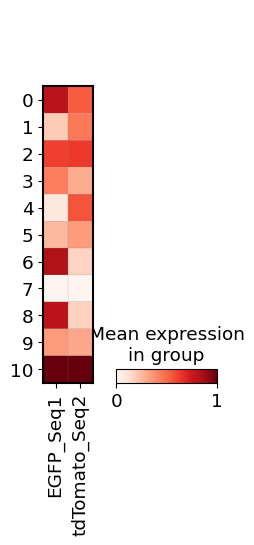

In [14]:
genes = ['EGFP_Seq1', 'tdTomato_Seq2']
sc.pl.matrixplot(adata, var_names = genes, groupby = 'neuron_recluster', standard_scale = 'var', cmap = 'Reds')

=== neuron_recluster assignments for target cells ===
bpoikicj-1-1: 4
akcoadof-1-2: 4
bgmdeeeb-1-2: 4
hjjgalia-1-2: 4
bmjgagok-1-3: 4
ijnggkoc-1-3: 4


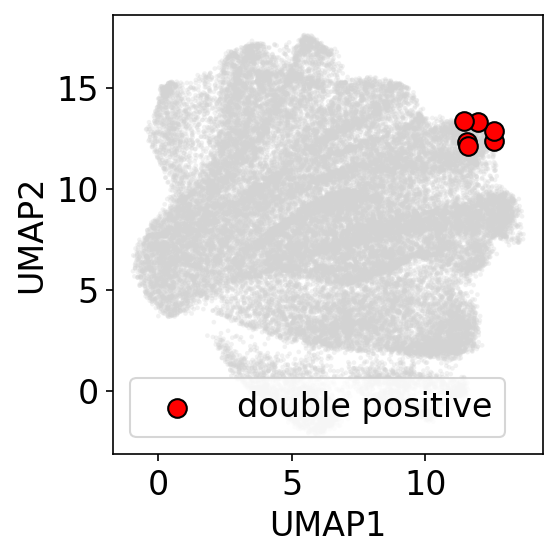

In [15]:
# List of barcodes you want to locate
targets = [
    "bpoikicj-1-1",
    "akcoadof-1-2",
    "bgmdeeeb-1-2",
    "hjjgalia-1-2",
    "bmjgagok-1-3",
    "ijnggkoc-1-3",
]

# Make a boolean mask for adata.obs_names
mask = adata.obs_names.isin(targets)

# Get UMAP coordinates
x = adata.obsm["X_umap"][:, 0]
y = adata.obsm["X_umap"][:, 1]

print("=== neuron_recluster assignments for target cells ===")
for bc in targets:
    if bc in adata.obs_names:
        cluster_id = adata.obs.loc[bc, "neuron_recluster"]
        print(f"{bc}: {cluster_id}")
    else:
        print(f"{bc}: NOT FOUND in adata")

plt.figure(figsize=(4, 4), dpi=150)

# plot all cells lightly
plt.scatter(
    x, y,
    s=5, c="lightgray", alpha=0.3,
    edgecolor="none"
)

# plot target cells in red
plt.scatter(
    x[mask], y[mask],
    s=80,
    c="red",
    edgecolor="black",
    linewidths=1,
    label="double positive"
)

plt.legend()
plt.title("")
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")

plt.tight_layout()
plt.show()

In [16]:
adata

AnnData object with n_obs × n_vars = 37176 × 212
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'output_id', 'xenium_run_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'nuclear_fraction', 'doublet_scores', 'predicted_doublets', 'batch', 'slide', '_scvi_batch', '_scvi_labels', 'scvi_model', 'leiden_scVI_1', 'cell_class', 'neuron_recluster', 'scanvi_labels'
    var: 'Ensembl ID', 'Probesets', 'zhen_list', 'spectral_panel', 'neurons_supervised', 'neurons_unsupervised', 'glia_supervised', 'glia_unsupervised', 'other', 'neuron_DEGs', 'neuron_detection_rate', 'glia_detection_rate', 'combined_detection_rate

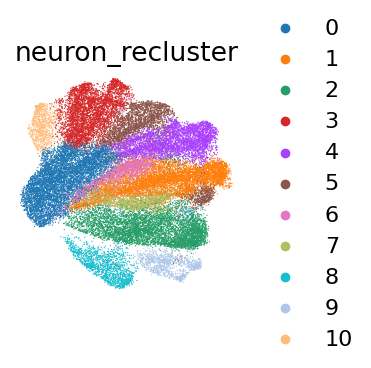

In [17]:
sc.pl.umap(adata, color = 'neuron_recluster', frameon = False)

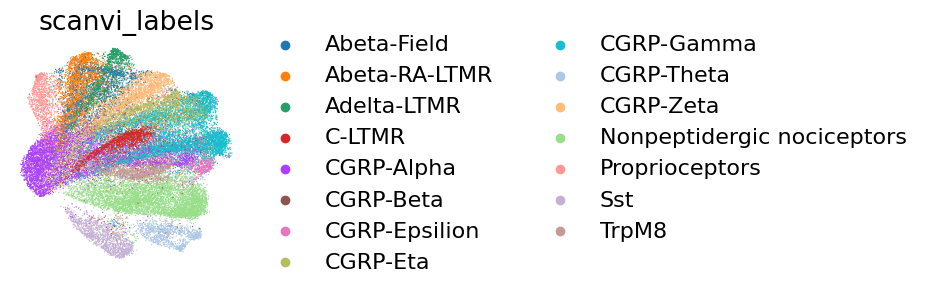

In [18]:
sc.pl.umap(adata, color = 'scanvi_labels', frameon = False)

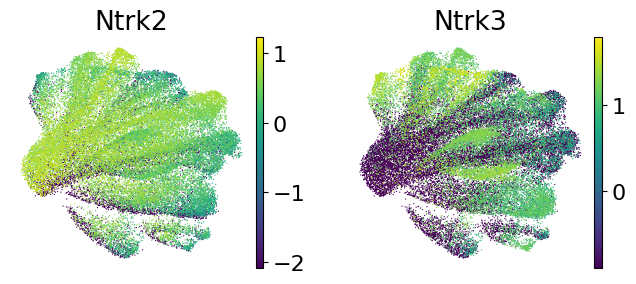

In [19]:
sc.pl.umap(adata, color = ['Ntrk2', 'Ntrk3'], frameon = False, use_raw = False)

# SINGLE GAUSSIAN SIMPLIFIED

In [20]:
base_dir = Path('/home/workspace/projects/20251125_drg-backup-slides1-2_gpu')
input_dir = base_dir / "data/h5ad/export_02/03_annotated"

### Read and process adata

In [21]:
adata = sc.read_h5ad(os.path.join(input_dir, 'ModelA_whole_all_annotated.h5ad'))
adata_ref = sc.read_h5ad(os.path.join(input_dir, 'ModelA_whole_all_annotated.h5ad'))

# have to use the version of the dataset that has the transgenes to draw positive and negative signal

#bdata = sc.read_h5ad(os.path.join(input_dir, 'ModelB_whole_noTG_annotated.h5ad'))
# this is the dataset with adata.var subsetted to 475, 5 transgenes witheld


In [22]:
adata.X = adata.layers['counts'].copy()
adata_ref.X = adata_ref.layers['counts'].copy()

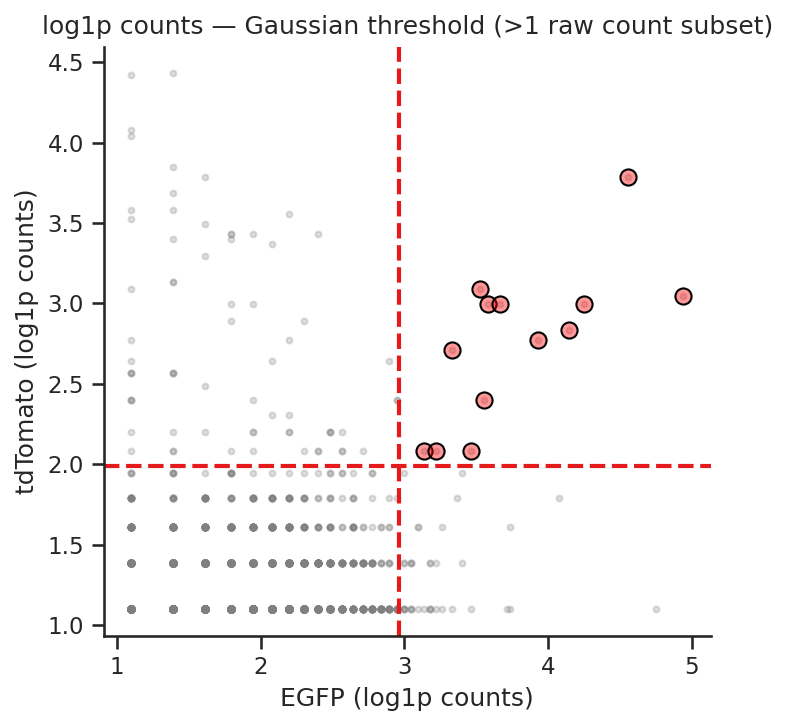

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="ticks")

adata = adata_ref.copy()

genes = ['EGFP_Seq1', 'tdTomato_Seq2']

def to_dense(x):
    return x.toarray().ravel() if hasattr(x, "toarray") else np.ravel(x)

# Raw counts for filtering
egfp_raw_all = to_dense(adata[:, "EGFP_Seq1"].X)
td_raw_all   = to_dense(adata[:, "tdTomato_Seq2"].X)

# Filter: only cells with >1 raw count in BOTH genes
bg_filter = (egfp_raw_all > 1) & (td_raw_all > 1)

gauss_results = {}

# -------- Fit a single Gaussian to log1p(counts) --------
for g in genes:
    x_raw_full = to_dense(adata[:, g].X)
    x_raw = x_raw_full[bg_filter]

    # log1p transform
    x_log = np.log1p(x_raw)

    # Fit a simple one-component Gaussian
    mu = np.mean(x_log)
    sigma = np.std(x_log)

    # 99th percentile of Gaussian = mean + 2.326 * sd
    thr_log = mu + 2.326 * sigma

    # call positives
    hi_mask = np.zeros(adata.n_obs, dtype=bool)
    hi_mask[bg_filter] = x_log > thr_log
    adata.obs[f"{g}_hi"] = hi_mask

    gauss_results[g] = {
        "x_log": x_log,
        "thr_log": thr_log,
        "mu": mu,
        "sigma": sigma
    }

# Dual-high
adata.obs['EGFP_tdTomato_dual_hi'] = (
    adata.obs['EGFP_Seq1_hi'] &
    adata.obs['tdTomato_Seq2_hi']
)

dual = adata.obs['EGFP_tdTomato_dual_hi'][bg_filter].values

# Extract for plotting
x_egfp_log = gauss_results["EGFP_Seq1"]["x_log"]
x_td_log   = gauss_results["tdTomato_Seq2"]["x_log"]
thr_egfp_log = gauss_results["EGFP_Seq1"]["thr_log"]
thr_td_log   = gauss_results["tdTomato_Seq2"]["thr_log"]

# -------- Plot --------
plt.figure(figsize=(5,5), dpi=150)
ax = plt.gca()

ax.scatter(x_egfp_log, x_td_log, s=8, color="gray", alpha=0.25)
ax.scatter(x_egfp_log[dual], x_td_log[dual],
           s=60, facecolors=(1,0,0,0.4), edgecolors="black")

ax.axvline(thr_egfp_log, color="#e41a1c", ls="--", lw=2)
ax.axhline(thr_td_log,   color="#e41a1c", ls="--", lw=2)

ax.set_xlabel("EGFP (log1p counts)")
ax.set_ylabel("tdTomato (log1p counts)")
ax.set_title("log1p counts — Gaussian threshold (>1 raw count subset)")

sns.despine()
plt.tight_layout()
plt.show()

In [24]:
# Print barcodes of dual-positive cells
dual_barcodes = adata.obs.index[adata.obs['EGFP_tdTomato_dual_hi']].tolist()

print("\nDual-positive barcodes:")
for bc in dual_barcodes:
    print(bc)

print(f"\nTotal: {len(dual_barcodes)} barcodes printed.")


Dual-positive barcodes:
apeeemip-1-1
bpoikicj-1-1
cbhmmeof-1-1
akcoadof-1-2
bgmdeeeb-1-2
hjjgalia-1-2
hjjkhdhk-1-2
mnhcfodp-1-2
bmjgagok-1-3
ijnggkoc-1-3
llknggjo-1-3
llmfnafp-1-3
llmgffik-1-3

Total: 13 barcodes printed.


## Area normalized

In [25]:
"""
adata = adata_ref.copy()

genes = ['EGFP_Seq1', 'tdTomato_Seq2']

def to_dense(x):
    return x.toarray().ravel() if hasattr(x, "toarray") else np.ravel(x)

# ---- true area normalization: counts per µm² ----
cell_area = adata.obs['cell_area'].values

# ---- raw counts for filtering ----
egfp_raw_all = to_dense(adata[:, "EGFP_Seq1"].X)
td_raw_all   = to_dense(adata[:, "tdTomato_Seq2"].X)

# keep only cells with >1 raw count (same filter logic)
bg_filter = (egfp_raw_all > 1) & (td_raw_all > 1)

gauss_results = {}

# -------- Fit a single Gaussian to log1p(area-normalized counts) --------
for g in genes:

    x_raw_full = to_dense(adata[:, g].X)
    x_raw = x_raw_full[bg_filter]

    # area-normalized expression (counts per µm²)
    x_norm = x_raw / cell_area[bg_filter]

    # log1p transform
    x_log = np.log1p(x_norm)

    # Gaussian parameters
    mu = np.mean(x_log)
    sigma = np.std(x_log)

    # 99th percentile of Gaussian = mean + 2.326 SD
    thr_log = mu + 2.326 * sigma

    # call positives
    hi_mask = np.zeros(adata.n_obs, dtype=bool)
    hi_mask[bg_filter] = x_log > thr_log
    adata.obs[f"{g}_hi"] = hi_mask

    gauss_results[g] = {
        "x_log": x_log,
        "thr_log": thr_log,
        "mu": mu,
        "sigma": sigma
    }

# ---- dual-high calls ----
adata.obs['EGFP_tdTomato_dual_hi'] = (
    adata.obs['EGFP_Seq1_hi'] &
    adata.obs['tdTomato_Seq2_hi']
)
dual = adata.obs['EGFP_tdTomato_dual_hi'][bg_filter].values

# ---- extract for plotting ----
x_egfp_log = gauss_results["EGFP_Seq1"]["x_log"]
x_td_log   = gauss_results["tdTomato_Seq2"]["x_log"]
thr_egfp_log = gauss_results["EGFP_Seq1"]["thr_log"]
thr_td_log   = gauss_results["tdTomato_Seq2"]["thr_log"]

# -------- plot --------
plt.figure(figsize=(5,5), dpi=150)
ax = plt.gca()

# all cells
ax.scatter(x_egfp_log, x_td_log, s=8, color="gray", alpha=0.25)

# dual-high cells
ax.scatter(
    x_egfp_log[dual], x_td_log[dual],
    s=60, facecolors=(1,0,0,0.4), edgecolors="black"
)

# thresholds
ax.axvline(thr_egfp_log, color="#e41a1c", ls="--", lw=2)
ax.axhline(thr_td_log,   color="#e41a1c", ls="--", lw=2)

ax.set_xlabel("EGFP (log1p counts per µm²)")
ax.set_ylabel("tdTomato (log1p counts per µm²)")
ax.set_title("Area-normalized log1p counts — single Gaussian fit")

sns.despine()
plt.tight_layout()
plt.show()
"""

'\nadata = adata_ref.copy()\n\ngenes = [\'EGFP_Seq1\', \'tdTomato_Seq2\']\n\ndef to_dense(x):\n    return x.toarray().ravel() if hasattr(x, "toarray") else np.ravel(x)\n\n# ---- true area normalization: counts per µm² ----\ncell_area = adata.obs[\'cell_area\'].values\n\n# ---- raw counts for filtering ----\negfp_raw_all = to_dense(adata[:, "EGFP_Seq1"].X)\ntd_raw_all   = to_dense(adata[:, "tdTomato_Seq2"].X)\n\n# keep only cells with >1 raw count (same filter logic)\nbg_filter = (egfp_raw_all > 1) & (td_raw_all > 1)\n\ngauss_results = {}\n\n# -------- Fit a single Gaussian to log1p(area-normalized counts) --------\nfor g in genes:\n\n    x_raw_full = to_dense(adata[:, g].X)\n    x_raw = x_raw_full[bg_filter]\n\n    # area-normalized expression (counts per µm²)\n    x_norm = x_raw / cell_area[bg_filter]\n\n    # log1p transform\n    x_log = np.log1p(x_norm)\n\n    # Gaussian parameters\n    mu = np.mean(x_log)\n    sigma = np.std(x_log)\n\n    # 99th percentile of Gaussian = mean + 2.32

In [26]:
"""
# Print barcodes of dual-positive cells
dual_barcodes = adata.obs.index[adata.obs['EGFP_tdTomato_dual_hi']].tolist()

print("\nDual-positive barcodes:")
for bc in dual_barcodes:
    print(bc)

print(f"\nTotal: {len(dual_barcodes)} barcodes printed.")
"""

'\n# Print barcodes of dual-positive cells\ndual_barcodes = adata.obs.index[adata.obs[\'EGFP_tdTomato_dual_hi\']].tolist()\n\nprint("\nDual-positive barcodes:")\nfor bc in dual_barcodes:\n    print(bc)\n\nprint(f"\nTotal: {len(dual_barcodes)} barcodes printed.")\n'

In [27]:
"""
sns.set_theme(style="ticks")

adata = adata_ref.copy()

genes = ['EGFP_Seq1', 'tdTomato_Seq2']

def to_dense(x):
    return x.toarray().ravel() if hasattr(x, "toarray") else np.ravel(x)

# ---- true area normalization: counts per µm² ----
cell_area = adata.obs['cell_area'].values

# ---- raw counts for filtering ----
egfp_raw_all = to_dense(adata[:, "EGFP_Seq1"].X)
td_raw_all   = to_dense(adata[:, "tdTomato_Seq2"].X)

# keep only cells with >1 raw count
bg_filter = (egfp_raw_all > 1) & (td_raw_all > 1)

gauss_results = {}

# -------- Fit a single Gaussian to log1p(area-normalized counts) --------
for g in genes:

    x_raw_full = to_dense(adata[:, g].X)
    x_raw = x_raw_full[bg_filter]

    # area-normalized expression (counts per µm²)
    x_norm = x_raw / cell_area[bg_filter]

    # log1p transform
    x_log = np.log1p(x_norm)

    # Gaussian parameters
    mu = np.mean(x_log)
    sigma = np.std(x_log)

    # 99th percentile of Gaussian
    thr_log = mu + 2.326 * sigma

    # call positives
    hi_mask = np.zeros(adata.n_obs, dtype=bool)
    hi_mask[bg_filter] = x_log > thr_log
    adata.obs[f"{g}_hi"] = hi_mask

    gauss_results[g] = {
        "x_log": x_log,
        "thr_log": thr_log,
        "mu": mu,
        "sigma": sigma
    }

# ---- dual-high calls ----
adata.obs['EGFP_tdTomato_dual_hi'] = (
    adata.obs['EGFP_Seq1_hi'] &
    adata.obs['tdTomato_Seq2_hi']
)
dual = adata.obs['EGFP_tdTomato_dual_hi'][bg_filter].values

# ---- extract for plotting ----
x_egfp_log = gauss_results["EGFP_Seq1"]["x_log"]
x_td_log   = gauss_results["tdTomato_Seq2"]["x_log"]
thr_egfp_log = gauss_results["EGFP_Seq1"]["thr_log"]
thr_td_log   = gauss_results["tdTomato_Seq2"]["thr_log"]

# ---- color by Leiden cluster ----
cluster_vals = adata.obs['leiden_scVI_1'][bg_filter].astype(int)

# -------- plot --------
plt.figure(figsize=(6,5), dpi=150)
ax = plt.gca()

# all cells, colored by cluster
scatter = ax.scatter(
    x_egfp_log,
    x_td_log,
    s=12,
    c=cluster_vals,
    cmap="tab20",
    alpha=0.7
)

# dual-high cells outlined in black
ax.scatter(
    x_egfp_log[dual], x_td_log[dual],
    s=80,
    facecolors='none',
    edgecolors='black',
    linewidths=1.0,
    label="Dual-high"
)

# thresholds
ax.axvline(thr_egfp_log, color="#e41a1c", ls="--", lw=2)
ax.axhline(thr_td_log,   color="#e41a1c", ls="--", lw=2)

ax.set_xlabel("EGFP (log1p counts per µm²)")
ax.set_ylabel("tdTomato (log1p counts per µm²)")
ax.set_title("Area-normalized log1p counts — single Gaussian fit")

# cluster legend
handles, labels = scatter.legend_elements(prop="colors")
plt.legend(handles, labels, title="Leiden cluster",
           bbox_to_anchor=(1.05, 1), loc="upper left")

sns.despine()
plt.tight_layout()
plt.show()
"""

'\nsns.set_theme(style="ticks")\n\nadata = adata_ref.copy()\n\ngenes = [\'EGFP_Seq1\', \'tdTomato_Seq2\']\n\ndef to_dense(x):\n    return x.toarray().ravel() if hasattr(x, "toarray") else np.ravel(x)\n\n# ---- true area normalization: counts per µm² ----\ncell_area = adata.obs[\'cell_area\'].values\n\n# ---- raw counts for filtering ----\negfp_raw_all = to_dense(adata[:, "EGFP_Seq1"].X)\ntd_raw_all   = to_dense(adata[:, "tdTomato_Seq2"].X)\n\n# keep only cells with >1 raw count\nbg_filter = (egfp_raw_all > 1) & (td_raw_all > 1)\n\ngauss_results = {}\n\n# -------- Fit a single Gaussian to log1p(area-normalized counts) --------\nfor g in genes:\n\n    x_raw_full = to_dense(adata[:, g].X)\n    x_raw = x_raw_full[bg_filter]\n\n    # area-normalized expression (counts per µm²)\n    x_norm = x_raw / cell_area[bg_filter]\n\n    # log1p transform\n    x_log = np.log1p(x_norm)\n\n    # Gaussian parameters\n    mu = np.mean(x_log)\n    sigma = np.std(x_log)\n\n    # 99th percentile of Gaussian\n

# Area visuslizsation

## Read data

In [28]:
#input_dir = base_dir / "data/h5ad/export_02/03_annotated"
#adata = sc.read_h5ad(os.path.join(input_dir, 'ModelA_whole_all_annotated.h5ad'))
#adata_ref = sc.read_h5ad(os.path.join(input_dir, 'ModelA_whole_all_annotated.h5ad'))

input_dir = base_dir / "data/h5ad/export_03/03_neuron-scanvi"
bdata = sc.read_h5ad(os.path.join(input_dir, 'neuron-scanvi-labels.h5ad'))

In [29]:
bdata.obs['EGFP_tdTomato_dual_hi'] = (
    adata.obs['EGFP_tdTomato_dual_hi']
    .reindex(bdata.obs_names)
    .fillna(False)
    .astype(bool)
)

In [30]:
area_all = bdata.obs['cell_area'].values
dual_mask = bdata.obs['EGFP_tdTomato_dual_hi'].values

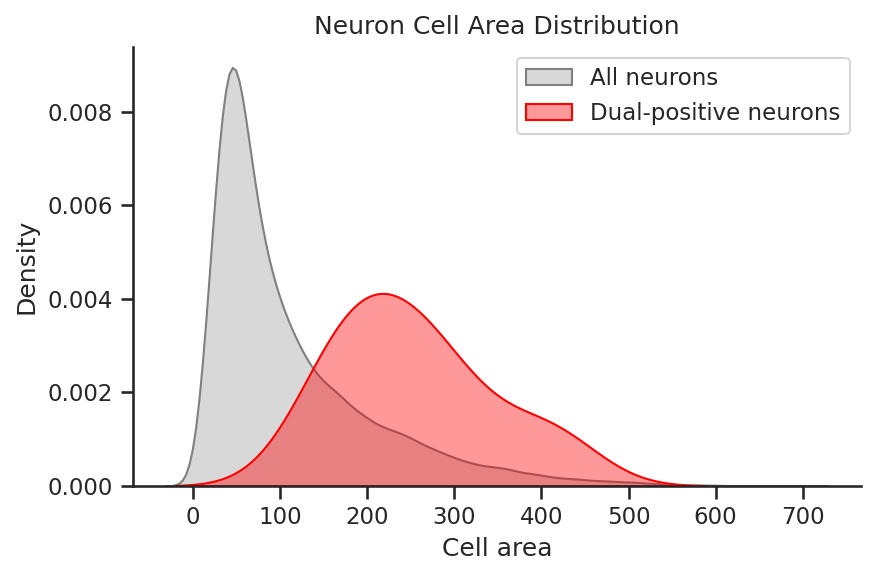

In [31]:
plt.figure(figsize=(6,4), dpi=150)
ax = plt.gca()

# KDE — all neuron cells
sns.kdeplot(
    area_all,
    fill=True,
    color="gray",
    alpha=0.3,
    ax=ax,
    label="All neurons"
)

# KDE — dual-positive neurons
sns.kdeplot(
    area_all[dual_mask],
    fill=True,
    color="red",
    alpha=0.4,
    ax=ax,
    label="Dual-positive neurons"
)

# Labels / formatting
ax.set_xlabel("Cell area")
ax.set_ylabel("Density")
ax.set_title("Neuron Cell Area Distribution")
ax.legend()

sns.despine()
plt.tight_layout()
plt.show()

/tmp/ipykernel_7488/1522270.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


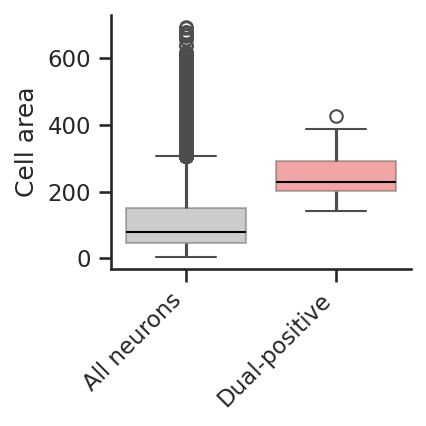

In [32]:
# -------------------------------------------------------------
# 1. Transfer dual-positive annotation from adata → bdata
# -------------------------------------------------------------
bdata.obs['EGFP_tdTomato_dual_hi'] = (
    adata.obs['EGFP_tdTomato_dual_hi']
    .reindex(bdata.obs_names)
    .fillna(False)
    .astype(bool)
)

# -------------------------------------------------------------
# 2. Build plotting frame
# -------------------------------------------------------------
plot_df = pd.DataFrame({
    'cell_area': bdata.obs['cell_area'],
    'group': bdata.obs['EGFP_tdTomato_dual_hi'].map(
        {False: 'All neurons', True: 'Dual-positive'}
    )
})

# -------------------------------------------------------------
# 3. Boxplot ONLY (swarm removed)
# -------------------------------------------------------------
plt.figure(figsize=(3,3), dpi=150)

ax = sns.boxplot(
    data=plot_df,
    x="group",
    y="cell_area",
    palette=["gray", "red"],
    showcaps=True,
    boxprops={'alpha': 0.4},
    medianprops={'color': 'black'},
    whiskerprops={'linewidth': 1.5}
)

# NO swarmplot here

# labels & title
ax.set_xlabel("")
ax.set_ylabel("Cell area")
ax.set_title("")
plt.xticks(rotation=45, ha="right")

sns.despine()
plt.tight_layout()
plt.show()

/tmp/ipykernel_7488/4277512170.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


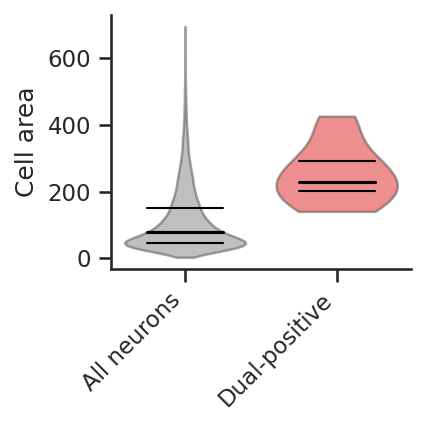

In [33]:
# -------------------------------------------------------------
# 1. Transfer dual-positive annotation from adata → bdata
# -------------------------------------------------------------
bdata.obs['EGFP_tdTomato_dual_hi'] = (
    adata.obs['EGFP_tdTomato_dual_hi']
    .reindex(bdata.obs_names)
    .fillna(False)
    .astype(bool)
)

# -------------------------------------------------------------
# 2. Build plotting dataframe
# -------------------------------------------------------------
plot_df = pd.DataFrame({
    'cell_area': bdata.obs['cell_area'],
    'group': bdata.obs['EGFP_tdTomato_dual_hi'].map(
        {False: 'All neurons', True: 'Dual-positive'}
    )
})

# -------------------------------------------------------------
# 3. Fancy violin plot
# -------------------------------------------------------------
plt.figure(figsize=(3,3), dpi=150)
ax = plt.gca()

palette = {"All neurons": "gray", "Dual-positive": "red"}

sns.violinplot(
    data=plot_df,
    x="group",
    y="cell_area",
    palette=palette,
    inner=None,
    linewidth=1.2,
    cut=0,
    alpha=0.5,
    ax=ax
)

# -------------------------------------------------------------
# 4. Add quartile lines (Q1, median, Q3)
# -------------------------------------------------------------
for i, group in enumerate(plot_df["group"].unique()):
    vals = plot_df.loc[plot_df["group"] == group, "cell_area"].values
    q1 = np.percentile(vals, 25)
    med = np.percentile(vals, 50)
    q3 = np.percentile(vals, 75)

    ax.plot([i-0.25, i+0.25], [q1, q1], color="black", lw=1)
    ax.plot([i-0.25, i+0.25], [med, med], color="black", lw=1.5)
    ax.plot([i-0.25, i+0.25], [q3, q3], color="black", lw=1)

# (Swarmplot block removed)

# Formatting
ax.set_xlabel("")
ax.set_ylabel("Cell area")
ax.set_title("")

# ---- Rotate x-axis labels 45 degrees ----
plt.xticks(rotation=45, ha="right")

sns.despine()
plt.tight_layout()
plt.show()

In [34]:
from scipy.stats import mannwhitneyu

# Split into groups
area_all = plot_df.loc[plot_df["group"] == "All neurons", "cell_area"].values
area_dual = plot_df.loc[plot_df["group"] == "Dual-positive", "cell_area"].values

# Mann–Whitney U test (two-sided)
stat, p = mannwhitneyu(area_all, area_dual, alternative="two-sided")

print("Mann–Whitney U test")
print(f"U-statistic = {stat:.2f}")
print(f"p-value      = {p:.3e}")

Mann–Whitney U test
U-statistic = 53855.00
p-value      = 5.363e-06


In [35]:
from scipy.stats import mannwhitneyu, combine_pvalues

pvals = []
stats = []

for rep in bdata.obs['output_id'].unique():
    sub = plot_df[bdata.obs['output_id'] == rep]
    
    area_all = sub.loc[sub["group"] == "All neurons", "cell_area"].values
    area_dual = sub.loc[sub["group"] == "Dual-positive", "cell_area"].values
    
    if len(area_all) > 0 and len(area_dual) > 0:
        stat, p = mannwhitneyu(area_all, area_dual, alternative="two-sided")
        stats.append(stat)
        pvals.append(p)
        print(f"Replicate {rep}: U={stat:.1f}, p={p:.3e}")
    else:
        print(f"Replicate {rep}: insufficient data")

# Combine replicate p-values (Fisher method)
combined_stat, combined_p = combine_pvalues(pvals, method='fisher')

print("Combined significance across replicates")
print(f"Fisher X^2 = {combined_stat:.2f}")
print(f"Combined p-value = {combined_p:.3e}")

Replicate TMA00303: insufficient data
Replicate TMA00304: U=1257.0, p=3.741e-02
Replicate TMA00305: U=6773.5, p=2.522e-03
Replicate TMA00306: U=8554.5, p=5.461e-03
Combined significance across replicates
Fisher X^2 = 28.96
Combined p-value = 6.197e-05
